In [1]:
import math

import mpmath
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Math, display
from scipy.optimize import least_squares
from scipy.signal import argrelextrema


In [2]:
def chebyshev_nodes(a, b, n):
    """
    Calculate n+1 Chebyshev nodes for the interval [a, b].
    
    Parameters:
    - a: Lower bound of the interval.
    - b: Upper bound of the interval.
    - n: Degree of the polynomial.
    
    Returns:
    - An array of n+1 Chebyshev nodes.
    """
    i = np.arange(n+1)
    x = np.cos((2*i+1) * np.pi / (2*n+2))  # Chebyshev nodes in [-1, 1]
    return 0.5 * ((b-a) * x + a + b)  # Map nodes to [a, b]

# Example usage:
nodes = chebyshev_nodes(a=0, b=5, n=4)
print("Chebyshev nodes:", nodes)


Chebyshev nodes: [4.87764129 3.96946313 2.5        1.03053687 0.12235871]


[-1.92145227e-07  3.42878255e-06 -1.36752727e-06 -1.96660296e-04
 -1.45933598e-06  8.33412223e-03 -2.69162358e-07 -1.66666612e-01
 -5.82339432e-09  1.00000000e+00 -2.42687994e-12]
-9.39079097860391e-13


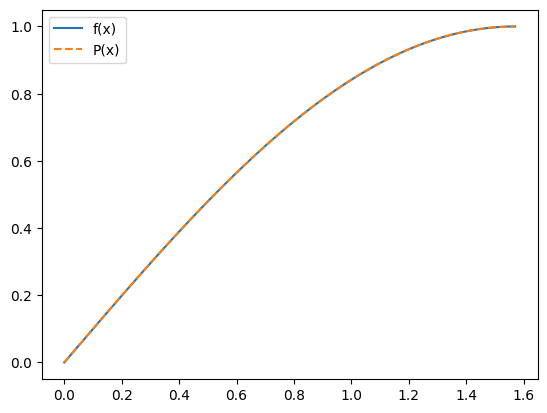

In [3]:
def remez_approximation(f, bounds, n):
    # Step 1: Choose n+2 sample points
    # x_points = np.linspace(bounds[0], bounds[1], n+2)
    x_points = chebyshev_nodes(bounds[0], bounds[1], n+1)
    
    # Step 2: Create the matrix A and vector b
    A = np.zeros((n+2, n+2))
    b = np.zeros(n+2)
    for i, x in enumerate(x_points):
        A[i, :-1] = [x**k for k in range(n+1)]
        A[i, -1] = (-1)**i
        b[i] = f(x)
    
    # Step 3: Solve the system of equations Ap = b
    p = np.linalg.solve(A, b)
    
    # Define the closure for polynomial evaluation
    def P(x):
        return np.polyval(p[:-1][::-1], x)
    
    return p[:-1][::-1], p[-1], P

# Example usage:
def f(x):
    return np.sin(x)  # Example function

bounds = [0, np.pi/2]  # Approximation bounds
n = 10  # Degree of the polynomial

p, E, P = remez_approximation(f, bounds, n)
print(p)
print(E)

# Evaluate and plot
import matplotlib.pyplot as plt
x_vals = np.linspace(bounds[0], bounds[1], 1000)
plt.plot(x_vals, f(x_vals), label='f(x)')
plt.plot(x_vals, P(x_vals), label='P(x)', linestyle='--')
plt.legend()


In [4]:
def format_polynomial(coeffs):
    """
    Format a list of polynomial coefficients as a polynomial string.
    
    Parameters:
    - coeffs: A list or array of coefficients in descending order.
    
    Returns:
    - A string representing the polynomial.
    """
    terms = []
    n = len(coeffs)
    
    for i, coeff in enumerate(coeffs):
        power = n - i - 1  # Calculate the power of x for the current coefficient
        
        # Skip zero coefficients
        if coeff == 0:
            continue
        
        # Handle the sign (+/-), except for the leading term
        sign = '-' if coeff < 0 else '+'
        if i == 0:  # Leading term has no sign
            sign = '' if coeff > 0 else '-'
        
        # Format the coefficient
        abs_coeff = abs(coeff)
        if abs_coeff == 1 and power != 0:  # Omit coefficient if it's 1 (except for the constant term)
            coeff_str = ''
        else:
            coeff_str = f'{abs_coeff}'
        
        # Format the term
        if power == 0:
            terms.append(f'{sign}{coeff_str}')
        elif power == 1:
            terms.append(f'{sign}{coeff_str}x')
        else:
            terms.append(f'{sign}{coeff_str}x^{power}')
    
    # Join all terms
    polynomial = ' '.join(terms).strip()
    
    return polynomial

# Example usage:
print(format_polynomial(p))


-1.9214522736568486e-07x^10 +3.4287825508465507e-06x^9 -1.3675272665823856e-06x^8 -0.00019666029608353402x^7 -1.4593359839257303e-06x^6 +0.008334122228211078x^5 -2.691623578907337e-07x^4 -0.1666666121682216x^3 -5.8233943236691655e-09x^2 +1.000000000258139x -2.4268799359486335e-12


In [5]:
from scipy.signal import argrelextrema

def error_analysis(f, P, interval, num_points=1000):
    """
    Evaluate the error |P(x) - f(x)| across the approximation interval and
    identify points of maximum deviation.
    
    Parameters:
    - f: The target function.
    - P: The polynomial approximation function.
    - interval: Tuple (a, b) representing the lower and upper bounds of the approximation interval.
    - num_points: Number of points to evaluate within the interval for finding maximum deviations.
    
    Returns:
    - extrema_points: Points in the interval where the error |P(x) - f(x)| reaches local maxima.
    - extrema_errors: The error values at the extrema points.
    """
    # Generate evaluation points
    x = np.linspace(interval[0], interval[1], num_points)
    
    # Calculate the error |P(x) - f(x)|
    error = np.abs(P(x) - f(x))
    
    # Find indices of local maxima in the error
    maxima_indices = argrelextrema(error, np.greater)[0]
    
    # Add endpoints to consider as potential maxima
    maxima_indices = np.concatenate(([0], maxima_indices, [num_points-1]))
    
    # Extract the points and errors at these maxima
    extrema_points = x[maxima_indices]
    extrema_errors = error[maxima_indices]
    
    return extrema_points, extrema_errors

In [6]:
ex, exe = error_analysis(f, P, bounds)
print(ex.shape, exe.shape)
print(max(exe))


(10,) (10,)
2.4268799359486335e-12


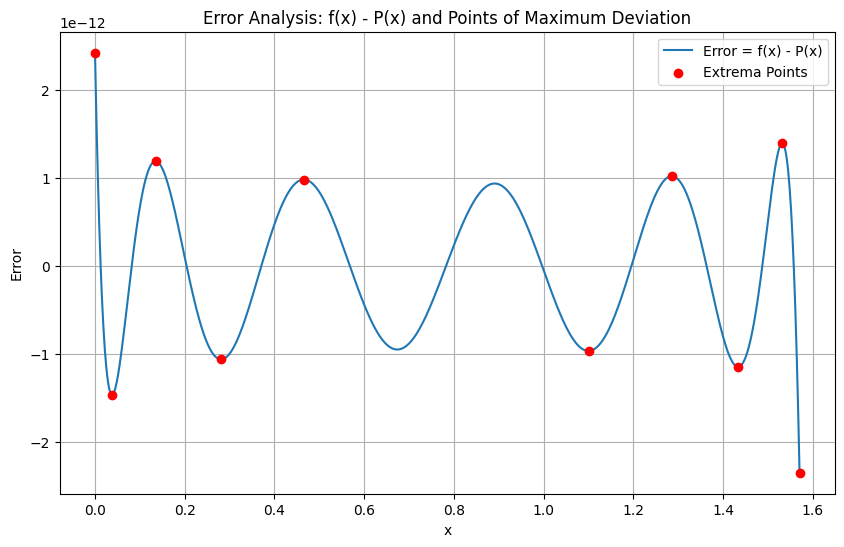

In [7]:

def plot_error_analysis(f, P, extrema_points, extrema_errors):
    # Generate points for plotting
    x_plot = np.linspace(bounds[0], bounds[1], 1000)
    error_plot = f(x_plot) - P(x_plot)
    
    # Plot f(x) - P(x) and mark the extrema points
    plt.figure(figsize=(10, 6))
    plt.plot(x_plot, error_plot, label='Error = f(x) - P(x)')
    plt.scatter(extrema_points, f(extrema_points) - P(extrema_points), color='red', zorder=5, label='Extrema Points')
    plt.xlabel('x')
    plt.ylabel('Error')
    plt.title('Error Analysis: f(x) - P(x) and Points of Maximum Deviation')
    plt.legend()
    plt.grid(True)
    plt.show()
    
plot_error_analysis(f, P, ex, exe)

In [8]:
def remez_step(f, x_points):
    n = len(x_points)-2
    
    # Step 2: Create the matrix A and vector b
    A = np.zeros((n+2, n+2))
    b = np.zeros(n+2)
    for i, x in enumerate(x_points):
        A[i, :-1] = [x**k for k in range(n+1)]
        A[i, -1] = (-1)**i
        b[i] = f(x)
    
    # Step 3: Solve the system of equations Ap = b
    p = np.linalg.solve(A, b)
    
    # Define the closure for polynomial evaluation
    def P(x):
        return np.polyval(p[:-1][::-1], x)
    
    return p[:-1][::-1], p[-1], P

In [9]:
p2, E2, P2 = remez_step(f, ex)
p2

array([ 1.71737185e-05, -2.45290448e-04,  7.00945577e-05,  8.27225227e-03,
        3.09303692e-05, -1.66675294e-01,  1.17583796e-06,  9.99999940e-01,
        5.01363104e-10])

In [10]:
ex2, exe2 = error_analysis(f, P2, bounds)
print(ex2.shape, exe2.shape)
print(max(exe2))

(10,) (10,)
2.4116637575843924e-09


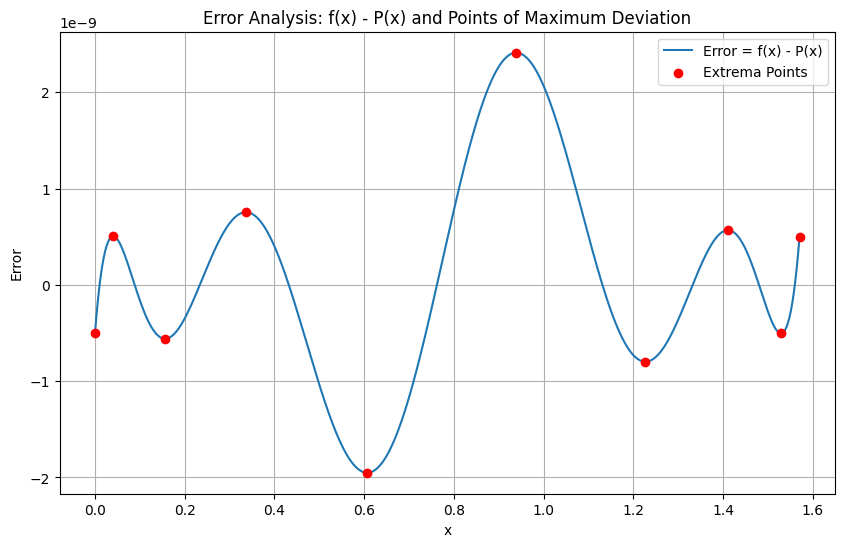

In [11]:
plot_error_analysis(f, P2, ex2, exe2)

In [12]:
p3, E3, P3 = remez_step(f, ex2)
p3

array([ 1.72058396e-05, -2.45704446e-04,  7.17636429e-05,  8.26913883e-03,
        3.39069428e-05, -1.66676735e-01,  1.49176583e-06,  9.99999916e-01,
        7.78343650e-10])

(10,) (10,)
9.914087328866117e-10


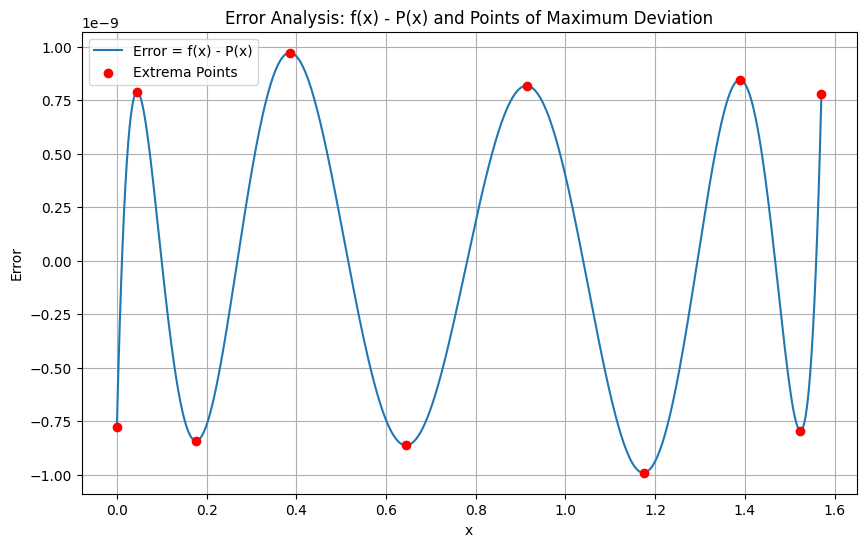

In [13]:
ex3, exe3 = error_analysis(f, P3, bounds)
print(ex3.shape, exe3.shape)
print(max(exe3))
plot_error_analysis(f, P3, ex3, exe3)

In [14]:
format_polynomial(p3)

'1.7205839570538653e-05x^8 -0.00024570444635781114x^7 +7.176364288048014e-05x^6 +0.008269138826766066x^5 +3.3906942770043264e-05x^4 -0.16667673455665638x^3 +1.491765834921741e-06x^2 +0.9999999156174182x +7.783436499070848e-10'

1.7209863008943345e-05x^8 -0.00024575124459624625x^7 +7.194649190849227e-05x^6 +0.008268794893899754x^5 +3.425379759410762e-05x^4 -0.16667692317020713x^3 +1.5422400957890642e-06x^2 +0.9999999106213322x +8.526477071446453e-10
(10,) (10,)
8.562690556601638e-10


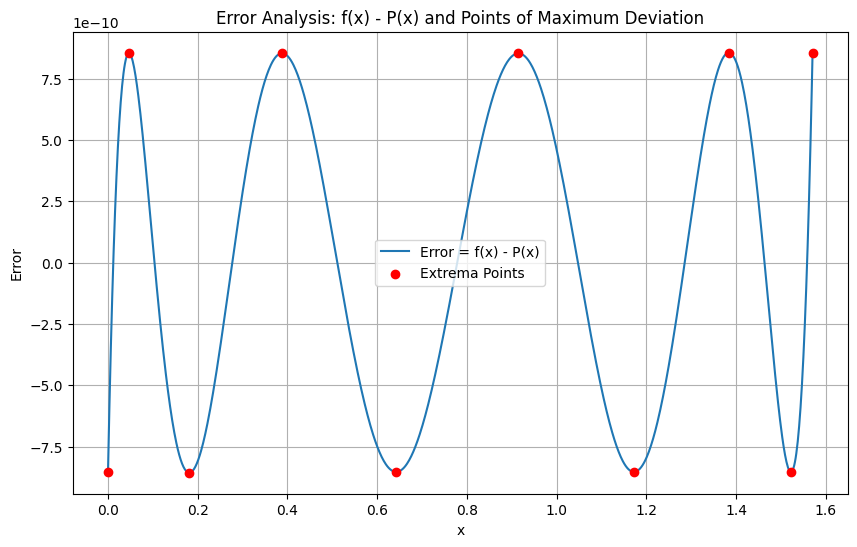

In [15]:
p4, E4, P4 = remez_step(f, ex3)
print(format_polynomial(p4))
ex4, exe4 = error_analysis(f, P4, bounds)
print(ex4.shape, exe4.shape)
print(max(exe4))
plot_error_analysis(f, P4, ex4, exe4)

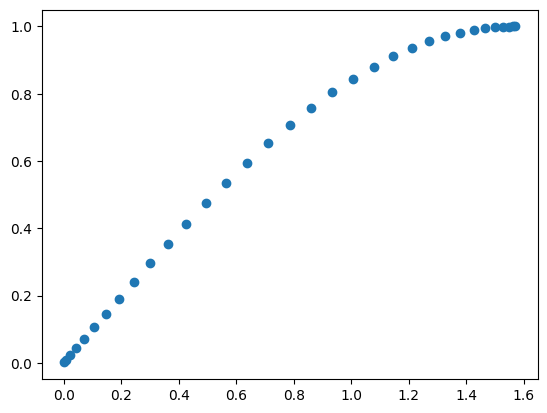

In [16]:
import numpy as np
from scipy.optimize import least_squares

# Suppose x_data and y_data are your N sampled points
k = 5
x_data = nodes = chebyshev_nodes(a=0, b=np.pi/2, n=32)
y_data = np.sin(x_data)
plt.scatter(x_data, y_data)

In [17]:
# Define the model function
def model(params, x):
    p = params[:k+1]  # Coefficients of P
    q = np.concatenate(([1], params[k+1:]))  # Coefficients of Q, fixing q0 = 1 for stability
    P_x = np.polyval(p[::-1], x)
    Q_x = np.polyval(q[::-1], x)
    return P_x / Q_x

# Define the objective function
def objective(params, x, y):
    return model(params, x) - y

# Initial guess for parameters
params_initial = np.zeros(2*k + 1)

# Perform the optimization
result = least_squares(objective, params_initial, args=(x_data, y_data))

# Extract optimized parameters
optimized_params = result.x
optimized_params

array([ 1.59075099e-11,  9.99999998e-01,  2.04576160e-02, -1.34403536e-01,
       -2.09800975e-03,  3.36220203e-03,  2.04575747e-02,  3.22634544e-02,
        1.31031993e-03,  4.08862349e-04,  4.44778079e-05])

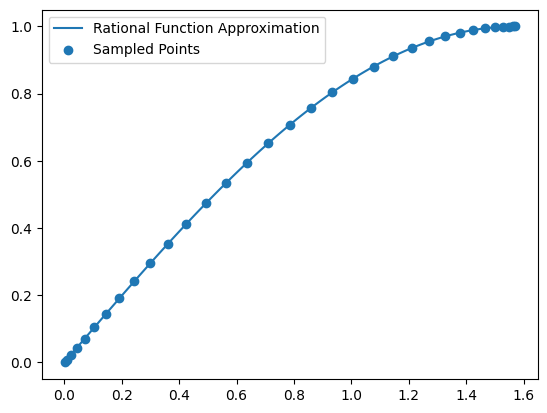

In [18]:
x_fill = np.linspace(0, np.pi/2, 100)
y_fill = np.array([ model(optimized_params, x) for x in x_fill ])
y_true = np.array([ np.sin(x) for x in x_fill ])
plt.plot(x_fill, y_fill, label='Rational Function Approximation')
plt.scatter(x_data, y_data, label='Sampled Points')
plt.legend()

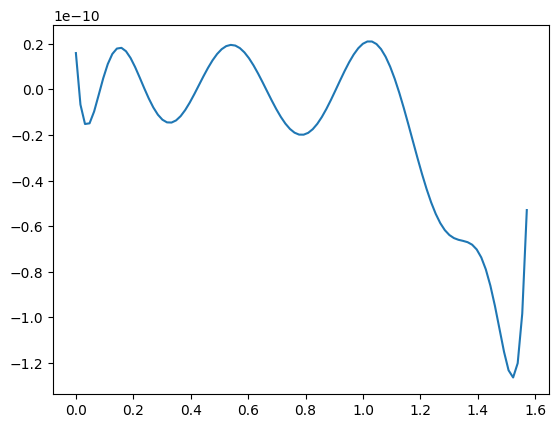

In [19]:
plt.plot(x_fill, y_fill-y_true)

In [20]:
from IPython.display import display, Math

def format_rational_function_to_latex(p_coeffs, q_coeffs):
    """
    Formats the given coefficients of P(x) and Q(x) into a LaTeX string.
    
    Parameters:
    - p_coeffs: Coefficients of the numerator polynomial P(x).
    - q_coeffs: Coefficients of the denominator polynomial Q(x).
    
    Returns:
    A LaTeX string representation of the rational function P(x)/Q(x).
    """
    def format_poly(coeffs):
        # Generate each term of the polynomial
        terms = []
        degree = len(coeffs) - 1
        for i, coeff in enumerate(coeffs):
            if coeff != 0:  # Only add non-zero terms
                # Format the coefficient
                coeff_str = '{:.9f}'.format(coeff).rstrip('0').rstrip('.') if coeff not in [-1, 1] or (degree - i) == 0 else '-' if coeff == -1 else ''

                # skip zero terms
                if coeff_str == '0':
                    pass
                    #continue
                    
                # Format the variable part    
                if (degree - i) > 0:
                    #if coeff_str == '1':
                    #    coeff_str = ''

                    x_str = 'x' if (degree - i) == 1 else 'x^{}'.format(degree - i)
                else:
                    x_str = ''
                terms.append(coeff_str + x_str)
        return ' + '.join(terms).replace('+ -', '- ')

    # Format the numerator and denominator
    p_str = format_poly(p_coeffs)
    q_str = format_poly(q_coeffs)

    # Combine to form the rational function string
    latex_str = f'\\frac{{{p_str}}}{{{q_str}}}'
    
    return latex_str


def display_rational_function(params, k):
    """
    Display a rational function given its parameters.

    Parameters:
    - params: Combined coefficients of P(x) and Q(x) in descending order.
    - k: The order of polynomials P(x) and Q(x).
    """
    p = params[:k+1]  # Coefficients of P
    q = np.concatenate(([1], params[k+1:]))  # Coefficients of Q, fixing q0 = 1 for stability

    # Use the existing function to format to LaTeX
    latex_str = format_rational_function_to_latex(p[::-1], q[::-1])
    
    # Display using Math for LaTeX rendering
    display(Math(latex_str))


display_rational_function(optimized_params, k)


<IPython.core.display.Math object>

In [21]:
len(optimized_params)

11

In [22]:
def model(params, x):
    p = params[:k+1]  # Coefficients of P
    print(p)
    q = np.concatenate(([1], params[k+1:]))  # Coefficients of Q, fixing q0 = 1 for stability
    print(q)
    P_x = np.polyval(p[::-1], x)
    Q_x = np.polyval(q[::-1], x)
    print(P_x, '/', Q_x)
    return P_x / Q_x

taylor coefficients: [0.0, 1.0, 0.0, -0.16666666666666666666666666666666666666666666666667, 0.0, 0.0083333333333333333333333333333333333333333333333333, 0.0, -0.0001984126984126984126984126984126984126984126984127, 0.0, 0.0000027557319223985890652557319223985890652557319223986, 0.0]
pade coefficients: [0.0, 1.0, 0.0, -0.13383838383838383838383838383838383838383838383838, 0.0, 0.0033128908128908128908128908128908128908128908128908] [1.0, 0.0, 0.032828282828282828282828282828282828282828282828283, 0.0, 0.00045093795093795093795093795093795093795093795093795, 0.0]


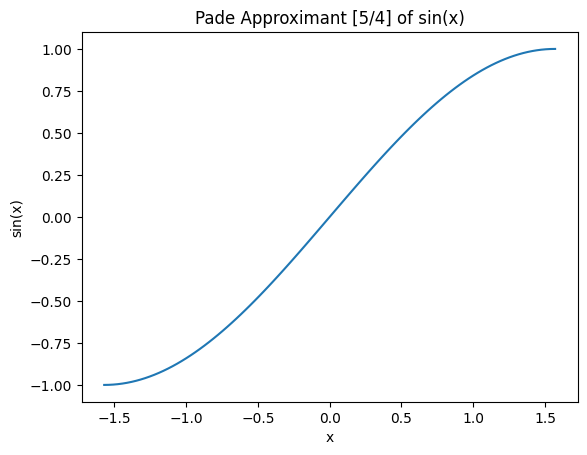

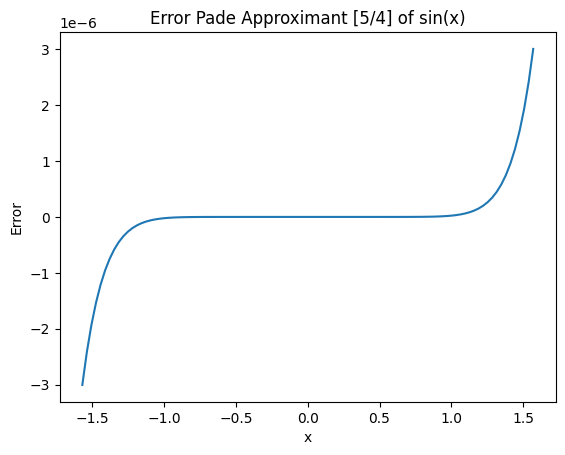

In [23]:
#from mpmath import *
import math
mpmath.mp.dps = 50
mpmath.mp.pretty = True

one = mpmath.mpf(1)

#def f(x):
#    return sqrt((one + 2*x)/(one + x))
f = mpmath.sin

p_degree = 5
q_degree = 4
taylor_degree = p_degree + q_degree + 1

a = mpmath.taylor(f, 0, taylor_degree)
print('taylor coefficients:', a)

#p, q = mpmath.pade(a, 3, 3)
p, q = mpmath.pade(a, p_degree, p_degree)
print('pade coefficients:', p, q)

xs = np.linspace(-math.pi/2, +math.pi/2, num=100)

@np.vectorize
def pade_approximant_sin(x):
    return mpmath.polyval(p[::-1], x) / mpmath.polyval(q[::-1], x)

ys = pade_approximant_sin(xs)
plt.plot(xs, ys)
plt.title(f"Pade Approximant [{p_degree}/{q_degree}] of sin(x)")
plt.xlabel('x')
plt.ylabel('sin(x)')
plt.show()

ys2 = [ mpmath.sin(x) for x in xs ]
error = ys - ys2
plt.plot(xs, error)
plt.title(f"Error Pade Approximant [{p_degree}/{q_degree}] of sin(x)")
plt.xlabel('x')
plt.ylabel('Error');

In [24]:
def format_poly(coeffs):
    # Generate each term of the polynomial
    terms = []
    degree = len(coeffs) - 1
    for i, coeff in enumerate(coeffs):
        if coeff != 0:  # Only add non-zero terms
            # Format the coefficient
            coeff_str = str(coeff).rstrip('0').rstrip('.') if coeff not in [-1, 1] or (degree - i) == 0 else '-' if coeff == -1 else ''

            # skip zero terms
            if coeff_str == '0':
                pass
                #continue
                
            # Format the variable part    
            if (degree - i) > 0:
                #if coeff_str == '1':
                #    coeff_str = ''

                x_str = 'x' if (degree - i) == 1 else 'x^{}'.format(degree - i)
            else:
                x_str = ''
            terms.append(coeff_str + x_str)
    return ' + '.join(terms).replace('+ -', '- ')



In [25]:
def format_rational(p_coeff, q_coeff):
    p_str = format_poly(p_coeff[::-1])
    q_str = format_poly(q_coeff[::-1])
    latex_str = f'\\frac{{{p_str}}}{{{q_str}}}'
    return Math(latex_str)

format_rational(p, q)

<IPython.core.display.Math object>